In [1]:
import tskit, pyslim, msprime
import numpy as np

In [2]:
import matplotlib.pyplot as plt

# dispersal rates

## true trees only

In [29]:
def exp_est_disp_plot(ds, tCutoffs, SIGMAdisps, nreps, string, K, SIGMAmate, xmax=None):

    # expected = [SIGMAdisp**2 for SIGMAdisp in SIGMAdisps] #ignores fact that higher variance to father
    expected = [(SIGMAdisp**2 + SIGMAmate**2/2) for SIGMAdisp in SIGMAdisps] #see Smith et al, https://academic.oup.com/genetics/article/224/2/iyad068/7117621
    
    fig, axs = plt.subplots(len(ds), len(tCutoffs), figsize=(5*len(ds),5*len(tCutoffs)))

    for i,d in enumerate(ds):
        for j,tCutoff in enumerate(tCutoffs):
            mless = []
            for SIGMAdisp in SIGMAdisps:
                mles = []
                for nrep in nreps:
                    mle = np.load(string %(K, SIGMAmate, SIGMAdisp, nrep, d, tCutoff))
                    mles.append(mle)
                mless.append(mles)
            mless = np.array(mless)

            ax = axs[j][i]
            ax.scatter([i for i in expected], [i for i in expected], c='k', marker='*')
    #         ax.plot([0,2], [0,2], c='k')
            ax.scatter([[i]*len(nreps) for i in expected], mless[:,:,0]**2, label='x', alpha=0.5, marker='x', color=ccolors(0))
            ax.scatter([[i]*len(nreps) for i in expected], mless[:,:,1]**2, label='y', alpha=0.5, marker='o', color=ccolors(0))
            ax.set_xlabel('expected dispersal rate')
            ax.set_ylabel('estimated dispersal rate')
    #         plt.legend()
            ax.set_title('d=%d, time cutoff=%s' %(d,tCutoff))
    #         plt.gca().set_aspect('equal')
            ax.set_xlim(0,xmax)
            ax.set_ylim(0,xmax)

    plt.show()

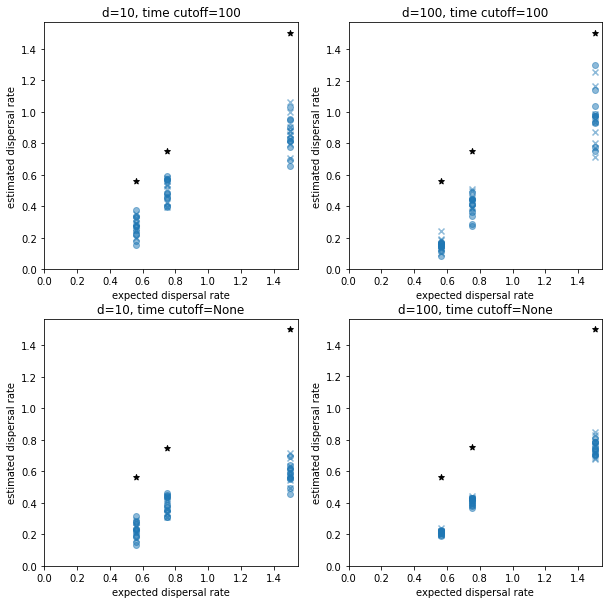

In [30]:
SIGMAmate = 1.0
K = 1.0
nreps = range(10)
tCutoffs = [100,'None']
ds = [10,100]
SIGMAdisps = [0.25,0.5,1.0]

string = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_%sK_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_%dd_50k_2G_100treeskip_%stCutoff_mle-dispersal.npy'

exp_est_disp_plot(ds, tCutoffs, SIGMAdisps, nreps, string, K, SIGMAmate)

### higher density

to simulate lower dispersal rate, which might show less boundary effects, we need a higher density of individuals, K. i think this is because of our non-overlapping generations: if there are more than K individuals in a unit area, they each have a mean number of offspring less than 1. so with small dispersal, if an individual has 2 offspring they will be in the same unit area, and with K=1 will both be subcritical. 

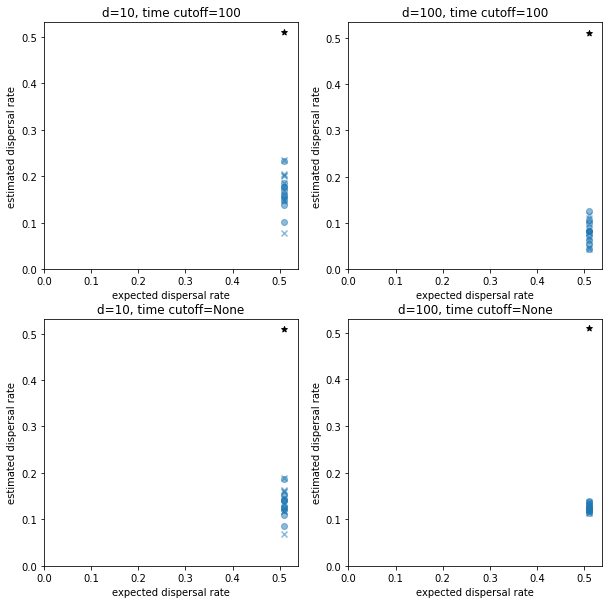

In [31]:
SIGMAmate = 1.0
K = 2.0
nreps = range(10)
tCutoffs = [100,'None']
ds = [10,100]
SIGMAdisps = [0.1]

string = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_%sK_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_%dd_50k_2G_100treeskip_%stCutoff_mle-dispersal.npy'

exp_est_disp_plot(ds, tCutoffs, SIGMAdisps, nreps, string, K, SIGMAmate)

### one genome per individual

can we do better if we take just one genome per individual? because then there will be more variance in sample locations

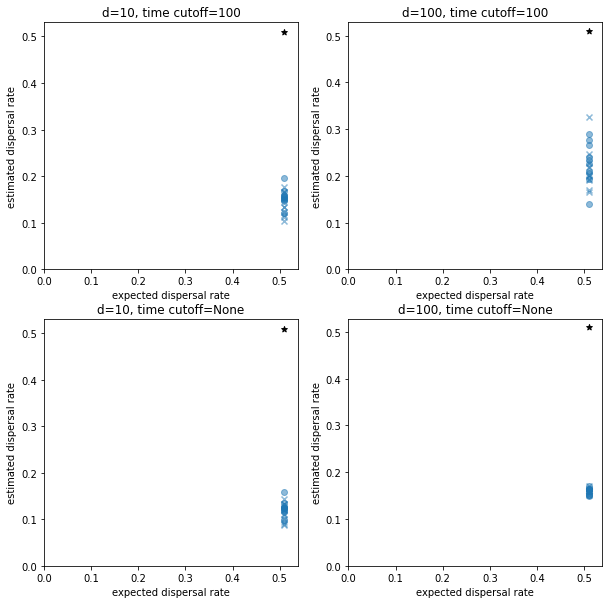

In [32]:
SIGMAmate = 1.0
K = 2.0
nreps = range(10)
tCutoffs = [100,'None']
ds = [10,100]
SIGMAdisps = [0.1]

string = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_%sK_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_%dd_100k_1G_100treeskip_%stCutoff_mle-dispersal.npy'

exp_est_disp_plot(ds, tCutoffs, SIGMAdisps, nreps, string, K, SIGMAmate)

## true vs inferred trees

In [3]:
def another_exp_est_disp_plot(d, tCutoff, SIGMAdisps, nreps, string, K, SIGMAmate, xmax=None):

    # expected = [SIGMAdisp**2 for SIGMAdisp in SIGMAdisps] #ignores fact that higher variance to father
    expected = [(SIGMAdisp**2 + SIGMAmate**2/2) for SIGMAdisp in SIGMAdisps] #see Smith et al, https://academic.oup.com/genetics/article/224/2/iyad068/7117621
    
    fig, axs = plt.subplots(1, 1, figsize=(5,5))

    mless = []
    for SIGMAdisp in SIGMAdisps:
        mles = []
        for nrep in nreps:
            mle = np.load(string %(K, SIGMAmate, SIGMAdisp, nrep, d, tCutoff))
            mles.append(mle)
        mless.append(mles)
    mless = np.array(mless)

    for i,ex in enumerate(expected):
        axs.scatter([ex for _ in nreps], mless[i,:,0]**2, label='$\sigma^2=$%s, x' %ex, alpha=0.5, color=ccolors(i), marker='x')
        axs.scatter([ex for _ in nreps], mless[i,:,1]**2, label='$\sigma^2=$%s, y' %ex, alpha=0.5, color=ccolors(i), marker='o')
        axs.scatter(ex, ex, marker='*')
    axs.set_xlabel('expected dispersal rate')
    axs.set_ylabel('estimated dispersal rate (true trees)')
#         plt.legend()
    ax.set_xlim(0,xmax)
    ax.set_ylim(0,xmax)

    plt.show()

In [4]:
def true_inf_disp_plot(d, tCutoff, SIGMAdisps, nreps, true_string, inferred_string, K, SIGMAmate, xmax=None):

    # expected = [SIGMAdisp**2 for SIGMAdisp in SIGMAdisps] #ignores fact that higher variance to father
    expected = [(SIGMAdisp**2 + SIGMAmate**2/2) for SIGMAdisp in SIGMAdisps] #see Smith et al, https://academic.oup.com/genetics/article/224/2/iyad068/7117621
    
    fig, axs = plt.subplots(1, 1, figsize=(5,5))

    mless = []
    for SIGMAdisp in SIGMAdisps:
        mles = []
        for nrep in nreps:
            mle = np.load(true_string %(K, SIGMAmate, SIGMAdisp, nrep, d, tCutoff))
            mles.append(mle)
        mless.append(mles)
    true_mless = np.array(mless)

    mless = []
    for SIGMAdisp in SIGMAdisps:
        mles = []
        for nrep in nreps:
            mle = np.load(inferred_string %(K, SIGMAmate, SIGMAdisp, nrep, d, tCutoff))
            mles.append(mle)
        mless.append(mles)
    inf_mless = np.array(mless)

    axs.plot([0,xmax], [0,xmax], c='k', zorder=0)
    for i,ex in enumerate(expected):
        axs.scatter(true_mless[i,:,0]**2, inf_mless[i,:,0]**2, label='$\sigma^2=$%s, x' %ex, alpha=0.5, color=ccolors(i), marker='x')
        axs.scatter(true_mless[i,:,1]**2, inf_mless[i,:,1]**2, label='$\sigma^2=$%s, y' %ex, alpha=0.5, color=ccolors(i), marker='o')
        axs.scatter(ex, ex, marker='*')
    # axs.scatter(true_mless[:,:,0], inf_mless[:,:,0], label='x', alpha=0.5)
    # axs.scatter(true_mless[:,:,1], inf_mless[:,:,1], label='y', alpha=0.5)
    axs.set_xlabel('dispersal rate from true trees')
    axs.set_ylabel('dispersal rate from inferred trees')
#     plt.legend()
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_1.0K_100W_1.0SIGMAcomp_1.0SIGMAmate_0.25SIGMAdisp_0selfing_40000MAXT_0nrep_10000Ne_1e-08U_100d_50k_2G_100treeskip_100tCutoff_mle-dispersal.npy'

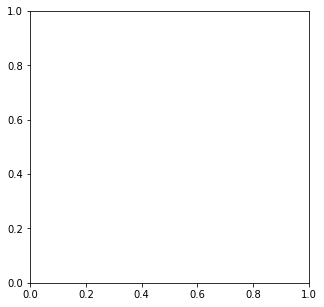

In [5]:
SIGMAmate = 1.0
K = 1.0
nreps = range(10)
tCutoff = 100
d = 100
SIGMAdisps = [0.25,0.5,1.0]

true_string = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_%sK_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_%dd_50k_2G_100treeskip_%stCutoff_mle-dispersal.npy'
inferred_string = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_%sK_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_%dd_50k_2G_5numiter_0.5threshold_100treeskip_1000M_%stCutoff_mle-dispersal.npy'

another_exp_est_disp_plot(d, tCutoff, SIGMAdisps, nreps, true_string, K, SIGMAmate, xmax=None)
true_inf_disp_plot(d, tCutoff, SIGMAdisps, nreps, true_string, inferred_string, K, SIGMAmate, xmax=3)

# ancestor locations

full tree

In [3]:
filename = "data/sim_100000000L_1e-08RBP_2.0LAMBDA_1.0K_100W_1.0SIGMAcomp_0.5SIGMAmate_0.5SIGMAdisp_0selfing_1001MAXT_0nrep.trees"
ts = tskit.load(filename)
ts

just samples

In [4]:
filename='data/sim_100000000L_1e-08RBP_2.0LAMBDA_1.0K_100W_1.0SIGMAcomp_0.5SIGMAmate_0.5SIGMAdisp_0selfing_1001MAXT_0nrep_10000Ne_1e-08U_100d_50k_2G.trees'
ts = tskit.load(filename)
ts

with ancestors

In [5]:
filename='data/sim_100000000L_1e-08RBP_2.0LAMBDA_1.0K_100W_1.0SIGMAcomp_0.5SIGMAmate_0.5SIGMAdisp_0selfing_1001MAXT_0nrep_10000Ne_1e-08U_100d_50k_2G_with_anc.trees'
ts_anc = tskit.load(filename)
ts_anc

In [7]:
[i.id for i in ts.individuals() if i.time==0]

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49]

check that the samples are labeled the same

In [10]:
[[ts.node(i).id, ts.individual(ts.node(i).individual).location] for i in ts.samples()][:10]

[[0, array([54.94545259, 90.02369028,  0.        ])],
 [1, array([54.94545259, 90.02369028,  0.        ])],
 [2, array([85.47158037,  3.74963608,  0.        ])],
 [3, array([85.47158037,  3.74963608,  0.        ])],
 [4, array([93.66421406, 90.24454067,  0.        ])],
 [5, array([93.66421406, 90.24454067,  0.        ])],
 [6, array([95.11403599, 69.48350037,  0.        ])],
 [7, array([95.11403599, 69.48350037,  0.        ])],
 [8, array([59.57062166,  8.95925387,  0.        ])],
 [9, array([59.57062166,  8.95925387,  0.        ])]]

In [11]:
[[ts_anc.node(i).id, ts_anc.individual(ts_anc.node(i).individual).location] for i in ts_anc.samples()][:10]

[[0, array([54.94545259, 90.02369028,  0.        ])],
 [1, array([54.94545259, 90.02369028,  0.        ])],
 [2, array([85.47158037,  3.74963608,  0.        ])],
 [3, array([85.47158037,  3.74963608,  0.        ])],
 [4, array([93.66421406, 90.24454067,  0.        ])],
 [5, array([93.66421406, 90.24454067,  0.        ])],
 [6, array([95.11403599, 69.48350037,  0.        ])],
 [7, array([95.11403599, 69.48350037,  0.        ])],
 [8, array([59.57062166,  8.95925387,  0.        ])],
 [9, array([59.57062166,  8.95925387,  0.        ])]]

real ancestor locationns

In [12]:
real_anc_locs = np.load('data/sim_100000000L_1e-08RBP_2.0LAMBDA_1.0K_100W_1.0SIGMAcomp_0.5SIGMAmate_0.5SIGMAdisp_0selfing_1001MAXT_0nrep_10000Ne_1e-08U_100d_50k_2G_100treeskip_anc-locs.npy')

In [13]:
real_anc_locs.shape

(17, 100, 11, 2)

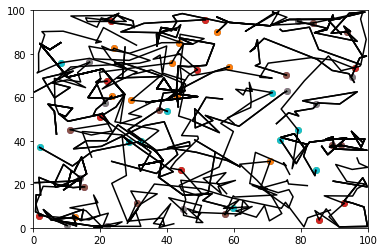

In [17]:
for alocs in real_anc_locs[:1]:
    for locs in alocs:
        plt.scatter(locs[0,0],locs[0,1])
        plt.plot(locs[:,0],locs[:,1], c='k')
    plt.xlim(0,100)
    plt.ylim(0,100)
    plt.show()

ancestor locations inferred from true trees

In [8]:
anc_locs = np.load('data/sim_100000000L_1e-08RBP_2.0LAMBDA_1.0K_100W_1.0SIGMAcomp_0.5SIGMAmate_0.5SIGMAdisp_0selfing_1001MAXT_0nrep_10000Ne_1e-08U_100d_50k_2G_100treeskip_NonetCutoff_ancestor-locations.npy')

In [19]:
anc_locs.shape

(10, 100, 11, 2)

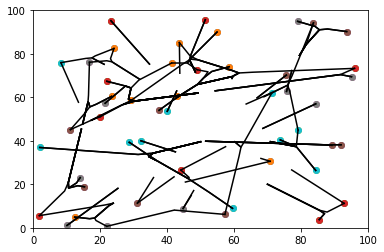

In [20]:
for alocs in anc_locs[:1]:
    for locs in alocs:
        plt.scatter(locs[0,0],locs[0,1])
        plt.plot(locs[:,0],locs[:,1], c='k')
    plt.xlim(0,100)
    plt.ylim(0,100)
    plt.show()

root mean squared error by time, in x dimension, with mean over all loci and samples

In [21]:
rmses = np.mean((real_anc_locs[:10,:,:,0] - anc_locs[:,:,:,0])**2, axis=(0,1))**0.5

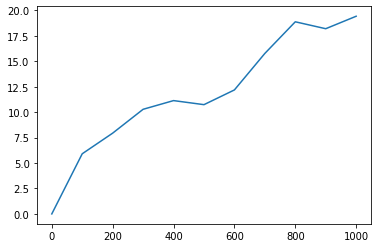

In [22]:
plt.plot(range(0,1001,100), rmses)
plt.show()

now look at ancestry clouds

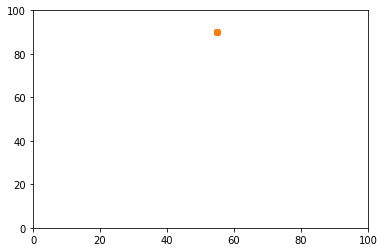

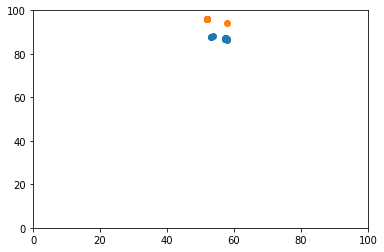

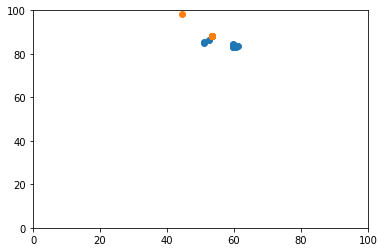

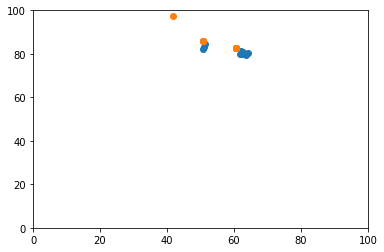

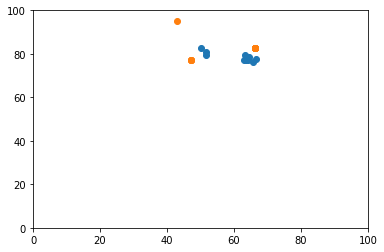

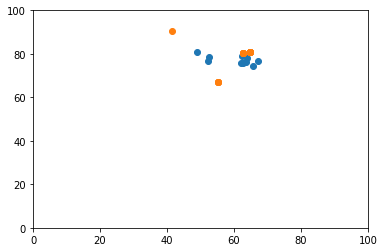

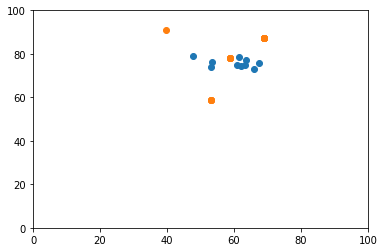

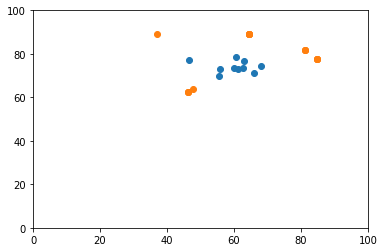

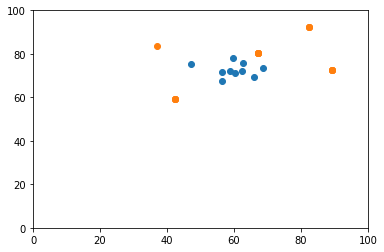

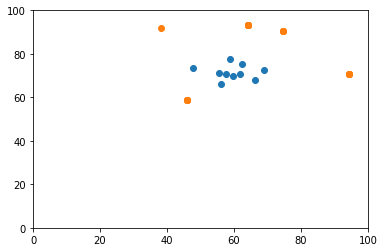

In [23]:
for i in range(10):
    plt.scatter(anc_locs[:10,0,i,0],anc_locs[:10,0,i,1])
    plt.scatter(real_anc_locs[:,0,i,0], real_anc_locs[:,0,i,1])
    plt.xlim(0,100)
    plt.ylim(0,100)
    plt.show()

In [24]:
rmses_clouds = np.mean((np.mean(real_anc_locs[:10,:,:,0], axis=0) - np.mean(anc_locs[:,:,:,0], axis=0))**2, axis=0)**0.5

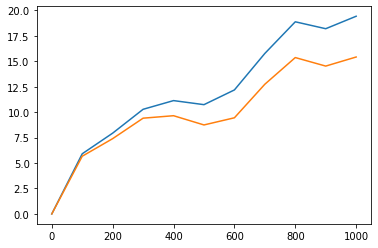

In [25]:
plt.plot(range(0,1001,100), rmses)
plt.plot(range(0,1001,100), rmses_clouds)
plt.show()

now scale up to longer sims and more loci, and replicate over sims

In [36]:
ts = tskit.load('data/sim_100000000L_1e-08RBP_2.0LAMBDA_1.0K_100W_1.0SIGMAcomp_1.0SIGMAmate_1.0SIGMAdisp_0selfing_1000MAXT_0nrep_10000Ne_1e-08U_100d_50k_2G_with_anc.trees')

In [37]:
def true_locations(tree, nodes, time):
    locs = np.empty((len(nodes),2))
    for i in tree.nodes():
        if ts.node(i).time==time:
            for leaf in tree.leaves(i):
                if leaf in nodes:
                    locs[leaf] = ts.individual(ts.node(i).individual).location[:2]
    return locs

In [38]:
tree = ts.first()
nodes = range(ts.num_samples)
time = 100
locs = true_locations(tree, nodes, time)

In [39]:
locs.shape

(100, 2)

In [40]:
times = range(0,1001,100)
all_locs = []
for time in times:
    locs = true_locations(tree, nodes, time)
    all_locs.append(locs)
all_locs = np.array(all_locs).swapaxes(0,1)

In [41]:
all_locs.shape

(100, 11, 2)

In [45]:
all_locs[:10,0]

array([[91.01486706, 51.3304194 ],
       [91.01486706, 51.3304194 ],
       [86.61323312, 26.86056613],
       [86.61323312, 26.86056613],
       [37.00977742, 34.9502534 ],
       [37.00977742, 34.9502534 ],
       [82.55444016, 46.76650425],
       [82.55444016, 46.76650425],
       [40.43249983, 93.2710191 ],
       [40.43249983, 93.2710191 ]])

In [47]:
anc_locs[0,:10,0]

array([[91.01486706, 51.3304194 ],
       [91.01486706, 51.3304194 ],
       [86.61323312, 26.86056613],
       [86.61323312, 26.86056613],
       [37.00977742, 34.9502534 ],
       [37.00977742, 34.9502534 ],
       [82.55444016, 46.76650425],
       [82.55444016, 46.76650425],
       [40.43249983, 93.2710191 ],
       [40.43249983, 93.2710191 ]])

In [49]:
retain_gens = range(100,1001,100)

In [50]:
retain_gens

range(100, 1001, 100)

In [56]:
times = [0]
times.append([i for i in retain_gens])

In [57]:
times

[0, [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]]

In [ ]:
for time in 

In [91]:
ts.individual(ts.node(10).individual).location

array([10.20738754, 60.74794534,  0.        ])

In [82]:
nodes = [i for i in tree.nodes() if ts.node(i).time==100]

In [85]:
[list(tree.leaves(node)) for node in nodes]

[[79],
 [63],
 [16],
 [49],
 [52, 53],
 [65, 84],
 [22],
 [91],
 [10],
 [29],
 [87],
 [89, 66],
 [73, 72],
 [88, 31],
 [30],
 [74],
 [34],
 [67],
 [64],
 [2],
 [7],
 [21],
 [86, 35],
 [48],
 [32],
 [9],
 [68],
 [44],
 [17],
 [81],
 [15],
 [5],
 [19, 18],
 [27],
 [0],
 [45],
 [1],
 [95],
 [85],
 [77, 76],
 [38],
 [54, 62],
 [39],
 [51],
 [98],
 [28],
 [93],
 [80],
 [69],
 [75],
 [58],
 [3],
 [4],
 [59],
 [78],
 [8],
 [11],
 [23, 90],
 [96],
 [97],
 [47, 46],
 [13],
 [50, 6, 12],
 [56],
 [92, 57],
 [20],
 [55, 94],
 [24, 61, 60],
 [14],
 [33],
 [83, 82],
 [25],
 [99],
 [26, 40, 41],
 [37],
 [36],
 [42],
 [71, 70],
 [43]]

In [2]:
import numpy as np

In [3]:
real_anc_locs = np.load("data/sim_100000000L_1e-08RBP_2.0LAMBDA_1.0K_100W_1.0SIGMAcomp_1.0SIGMAmate_1.0SIGMAdisp_0selfing_1000MAXT_0nrep_10000Ne_1e-08U_100d_50k_2G_100treeskip_anc-locs.npy")

In [4]:
real_anc_locs.shape

(514, 100, 10, 2)

In [5]:
anc_locs = np.load('data/sim_100000000L_1e-08RBP_2.0LAMBDA_1.0K_100W_1.0SIGMAcomp_1.0SIGMAmate_1.0SIGMAdisp_0selfing_1000MAXT_0nrep_10000Ne_1e-08U_100d_50k_2G_100treeskip_NonetCutoff_ancestor-locations.npy')

In [6]:
anc_locs.shape

(1794, 100, 11, 2)

two problems: need to add sample locations to real locs (easy) and use same trees as inferred locs (those ts have more trees due to recombination in recapitation)

may be more issues! see below

In [10]:
real_anc_locs[0,0]

array([[9.83760898e+001, 7.01191825e+001],
       [9.94458030e+001, 7.57689979e+001],
       [9.27877942e+001, 6.57447228e+001],
       [7.98723734e+001, 5.96343912e+001],
       [7.26650595e+001, 5.46110155e+001],
       [7.73463052e+001, 4.61881279e+001],
       [6.70817844e+001, 5.53404490e+001],
       [9.38726307e+001, 4.81703656e+001],
       [9.33201934e+001, 3.64163318e+001],
       [2.34820717e-310, 2.34820717e-310]])

In [11]:
anc_locs[0,1]

array([[91.01486706, 51.3304194 ],
       [90.50320794, 51.26507578],
       [89.99154882, 51.19973216],
       [89.4798897 , 51.13438854],
       [88.96823058, 51.06904492],
       [88.45657146, 51.0037013 ],
       [87.94491234, 50.93835768],
       [87.43325322, 50.87301406],
       [86.9215941 , 50.80767043],
       [86.40993498, 50.74232681],
       [85.89827586, 50.67698319]])

# anc locs from inferred trees

In [19]:
real_anc_locs = np.load('data/sim_100000000L_1e-08RBP_2.0LAMBDA_1.0K_100W_1.0SIGMAcomp_0.5SIGMAmate_0.25SIGMAdisp_0selfing_40000MAXT_1nrep_10000Ne_1e-08U_100d_50k_2G_100treeskip_anc-locs-inf.npy')
inf_anc_locs = np.load('data/sim_100000000L_1e-08RBP_2.0LAMBDA_1.0K_100W_1.0SIGMAcomp_0.5SIGMAmate_0.25SIGMAdisp_0selfing_40000MAXT_1nrep_10000Ne_1e-08U_100d_50k_2G_5numiter_0.5threshold_100treeskip_1locus_1000M_1000tCutoff_ancestor-locations.npy')

In [22]:
real_anc_locs.shape

(182, 100, 11, 2)

In [23]:
anc_locs.shape

(100, 11, 2)

In [24]:
real_anc_locs[0,2,:5]

array([[56.40471616, 93.27458302],
       [58.20242248, 90.84107222],
       [58.68697636, 90.28938397],
       [63.60605902, 91.81377854],
       [63.76318388, 92.55264378]])

In [25]:
anc_locs[2,:5]

array([[56.40471616, 93.27458302],
       [58.85591972, 91.5751711 ],
       [61.3545891 , 89.84283677],
       [61.88314873, 89.47640058],
       [61.88317867, 89.47632479]])

In [49]:
prefix = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_1.0K_100W_1.0SIGMAcomp_0.5SIGMAmate_0.25SIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_100d_50k_2G'

sse_mle = np.zeros(11)
sse_sample = np.zeros(11)
sse_mean_sample = np.zeros(11)
n = 0    
prefix_rep = prefix %1

filename = prefix_rep + '_100treeskip_anc-locs-inf.npy'
real_anc_locs = np.load(filename)[0]

filename = prefix_rep + '_5numiter_0.5threshold_100treeskip_1locus_1000M_1000tCutoff_ancestor-locations.npy'
inf_anc_locs = np.load(filename)

sse_mle += np.sum(np.sum((real_anc_locs - inf_anc_locs)**2, axis=-1), axis=0)

sample_locs = np.repeat(real_anc_locs[:,0,:], 11, axis=-2).reshape(real_anc_locs.shape) #locations of samples
sse_sample += np.sum(np.sum((real_anc_locs - sample_locs)**2, axis=-1), axis=0)

mean_loc = np.repeat(np.mean(real_anc_locs[:,0,:], axis=0), 11*100, axis=-1).reshape(real_anc_locs.shape) #mean sample location
sse_mean_sample += np.sum(np.sum((real_anc_locs - mean_loc)**2, axis=-1), axis=0)

n += len(real_anc_locs)
    
rmse_mle = (sse_mle/n)**0.5
rmse_sample = (sse_sample/n)**0.5
rmse_mean_sample = (sse_mean_sample/n)**0.5

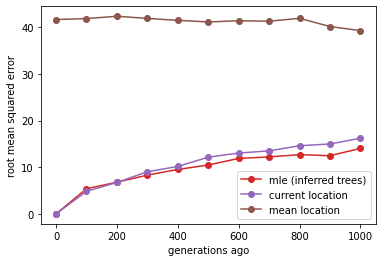

In [50]:
ccolors = plt.get_cmap('tab10')
plt.plot(range(0,1001,100), rmse_mle, marker='o', label='mle (inferred trees)', color=ccolors(3))
plt.plot(range(0,1001,100), rmse_sample, marker='o', label='current location', color=ccolors(4))
plt.plot(range(0,1001,100), rmse_mean_sample, marker='o', label='mean location', color=ccolors(5))

plt.xlabel('generations ago')
plt.ylabel('root mean squared error')
plt.legend()

# plt.savefig('plots/rmse-single-lineages.pdf')

plt.show()